# Data Exploration (Quality Inspection)

The purpose of this notebook is to inspect the raw WHO and World Bank datasets before cleaning. The goal of this notebook is not a thorough analysis but to:

• understand variable ranges  
• detect impossible values  
• detect missingness patterns  
• identify cleaning rules needed 

### Verifying Project Root
(this step is neccessary given we will have to work with nested directories)

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

print("Project root:", PROJECT_ROOT)

Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis


### Imports

In [5]:
from pathlib import Path
import yaml

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from life_expectancy.data.loading import load_source
from life_expectancy.data.standardization import standardize
from life_expectancy.data.utils import resolve_project_path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

## Loading standardized datasets

In [6]:
who_raw = load_source(config, "who")
who = standardize(who_raw, config["data"]["raw_sources"]["who"])

wb_raw = load_source(config, "wb")
wb = standardize(wb_raw, config["data"]["raw_sources"]["wb"])

wdi_raw = load_source(config, "wdi")
wdi = standardize(wdi_raw, config["data"]["raw_sources"]["wdi"])

### Basic Structure Check

In [7]:
print("WHO shape:", who.shape)
print("WB shape:", wb.shape)
print("WDI shape:", wdi.shape)

who.head()

WHO shape: (2938, 22)
WB shape: (3306, 16)
WDI shape: (266, 69)


,country,year,status,life_expectancy_who,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [8]:
wb.head()

,country,country_code,region,income_group,year,life_expectancy_wb,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,corruption,sanitation,injuries,communicable,noncommunicable_disease
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


## Column Overview

In [9]:
who.columns

Index(['country', 'year', 'status', 'life_expectancy_who', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

In [10]:
wb.columns

Index(['country', 'country_code', 'region', 'income_group', 'year',
       'life_expectancy_wb', 'undernourishment', 'co2',
       'health_expenditure_percent', 'education_expenditure_percent',
       'unemployment', 'corruption', 'sanitation', 'injuries', 'communicable',
       'noncommunicable_disease'],
      dtype='str')

In [11]:
wdi.columns

Index(['country', 'country_code', 'indicator_name', 'indicator_code', '1960',
       '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='str')

In [12]:
who.dtypes

country                             string
year                                 Int64
status                                 str
life_expectancy_who                float64
adult_mortality                    float64
infant_deaths                        int64
alcohol                            float64
percentage_expenditure             float64
hepatitis_b                        float64
measles                              int64
bmi                                float64
under_five_deaths                    int64
polio                              float64
total_expenditure                  float64
diphtheria                         float64
hiv_aids                           float64
gdp                                float64
population                         float64
thinness_1_19_years                float64
thinness_5_9_years                 float64
income_composition_of_resources    float64
schooling                          float64
dtype: object

In [13]:
wb.dtypes

country                           string
country_code                         str
region                               str
income_group                         str
year                               Int64
life_expectancy_wb               float64
undernourishment                 float64
co2                              float64
health_expenditure_percent       float64
education_expenditure_percent    float64
unemployment                     float64
corruption                       float64
sanitation                       float64
injuries                         float64
communicable                     float64
noncommunicable_disease          float64
dtype: object

In [14]:
wdi.dtypes

country            string
country_code       string
indicator_name     string
indicator_code     string
1960              float64
                   ...   
2020              float64
2021              float64
2022              float64
2023              float64
2024              float64
Length: 69, dtype: object

## Duplicate country-year check

In [15]:
who_duplicates = who.duplicated(subset=["country","year"]).sum()
wb_duplicates = wb.duplicated(subset=["country","year"]).sum()
wdi_duplicates = wdi.duplicated(subset=["country"]).sum()

print("WHO duplicate country-year rows:", who_duplicates)
print("WB duplicate country-year rows:", wb_duplicates)
print("WDI duplicate country rows:", wdi_duplicates)


WHO duplicate country-year rows: 0
WB duplicate country-year rows: 0
WDI duplicate country rows: 0


## Missing values overview

In [16]:
who.isna().sum().sort_values(ascending=False)

population                         652
hepatitis_b                        553
gdp                                448
total_expenditure                  226
alcohol                            194
income_composition_of_resources    167
schooling                          163
thinness_5_9_years                  34
thinness_1_19_years                 34
bmi                                 34
polio                               19
diphtheria                          19
life_expectancy_who                 10
adult_mortality                     10
hiv_aids                             0
country                              0
year                                 0
measles                              0
percentage_expenditure               0
infant_deaths                        0
status                               0
under_five_deaths                    0
dtype: int64

In [17]:
wb.isna().sum().sort_values(ascending=False)

corruption                       2331
sanitation                       1247
education_expenditure_percent    1090
undernourishment                  684
unemployment                      304
life_expectancy_wb                188
health_expenditure_percent        180
co2                               152
country                             0
country_code                        0
region                              0
income_group                        0
year                                0
injuries                            0
communicable                        0
noncommunicable_disease             0
dtype: int64

In [18]:
wdi.isna().sum().sort_values(ascending=False)

2024              266
1960                3
1964                3
1963                3
1965                3
                 ... 
2003                1
country_code        0
indicator_code      0
indicator_name      0
country             0
Length: 69, dtype: int64

## Life Expectancy (target variable inspection)

### WHO Dataset

In [19]:
who.describe()

,year,life_expectancy_who,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2938.0,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.51872,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.0,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.0,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.0,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.0,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.0,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [21]:
who["life_expectancy_who"].describe()

count    2928.000000
mean       69.224932
std         9.523867
min        36.300000
25%        63.100000
50%        72.100000
75%        75.700000
max        89.000000
Name: life_expectancy_who, dtype: float64

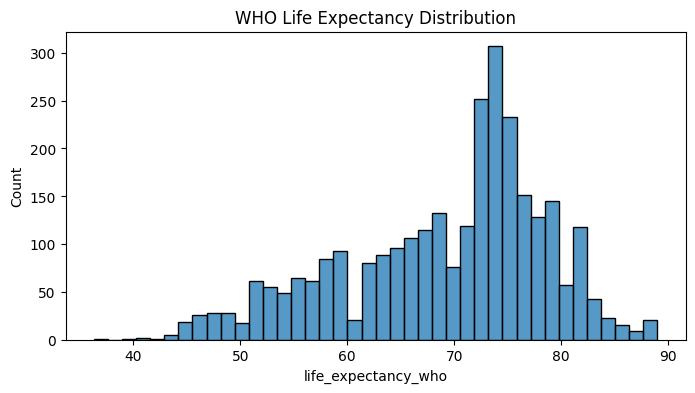

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(who["life_expectancy_who"], bins=40)
plt.title("WHO Life Expectancy Distribution")
plt.show()

In [24]:
who[who["life_expectancy_who"] <= 0]

,country,year,status,life_expectancy_who,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling


In [25]:
who[who["life_expectancy_who"] > 100]

,country,year,status,life_expectancy_who,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling


### WB Dataset

In [26]:
wb.describe()

,year,life_expectancy_wb,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,corruption,sanitation,injuries,communicable,noncommunicable_disease
count,3306.0,3118.000000,2622.000000,3.154000e+03,3126.000000,2216.000000,3002.000000,975.000000,2059.000000,3.306000e+03,3.306000e+03,3.306000e+03
mean,2010.0,69.748362,10.663654,1.574924e+05,6.364059,4.589014,7.890760,2.860513,52.738785,1.318219e+06,4.686289e+06,7.392488e+06
std,5.478054,9.408154,11.285897,7.726415e+05,2.842844,2.119165,6.270832,0.621343,30.126762,5.214068e+06,1.843727e+07,2.932688e+07
min,2001.0,40.369000,2.500000,1.000000e+01,1.263576,0.850320,0.100000,1.000000,2.377647,4.304900e+02,3.301600e+02,2.481820e+03
25%,2005.0,63.642000,2.500000,2.002500e+03,4.205443,3.136118,3.733000,2.500000,24.746007,6.245688e+04,5.776475e+04,3.184758e+05
50%,2010.0,72.168500,6.200000,1.020500e+04,5.892352,4.371465,5.920000,3.000000,49.317481,2.456910e+05,3.147693e+05,1.350146e+06
75%,2015.0,76.809000,14.775000,5.877250e+04,8.119166,5.519825,10.097500,3.250000,80.278847,8.465591e+05,2.831636e+06,3.918468e+06
max,2019.0,84.356341,70.900000,1.070722e+07,24.230680,23.270000,37.250000,4.500000,100.000004,5.563676e+07,2.685646e+08,3.246378e+08


In [27]:
wb["life_expectancy_wb"].describe()

count    3118.000000
mean       69.748362
std         9.408154
min        40.369000
25%        63.642000
50%        72.168500
75%        76.809000
max        84.356341
Name: life_expectancy_wb, dtype: float64

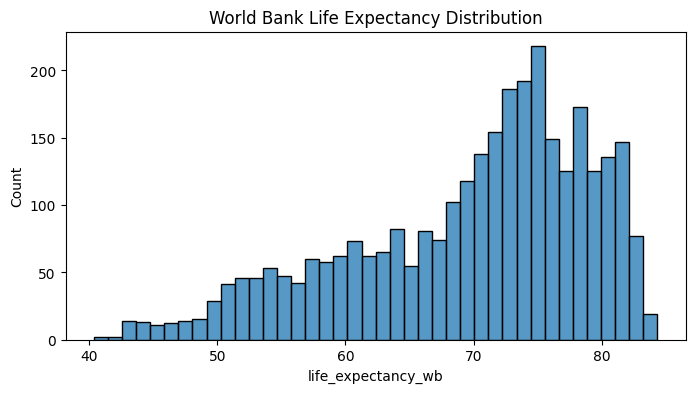

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(wb["life_expectancy_wb"], bins=40)
plt.title("World Bank Life Expectancy Distribution")
plt.show()

In [29]:
wb[wb["life_expectancy_wb"] <= 0]

,country,country_code,region,income_group,year,life_expectancy_wb,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,corruption,sanitation,injuries,communicable,noncommunicable_disease


In [30]:
wb[wb["life_expectancy_wb"] >= 100]

,country,country_code,region,income_group,year,life_expectancy_wb,undernourishment,co2,health_expenditure_percent,education_expenditure_percent,unemployment,corruption,sanitation,injuries,communicable,noncommunicable_disease


## Year Coverage

In [31]:
print("WHO years:", who["year"].min(), "-", who["year"].max())
print("WB years:", wb["year"].min(), "-", wb["year"].max())

WHO years: 2000 - 2015
WB years: 2001 - 2019


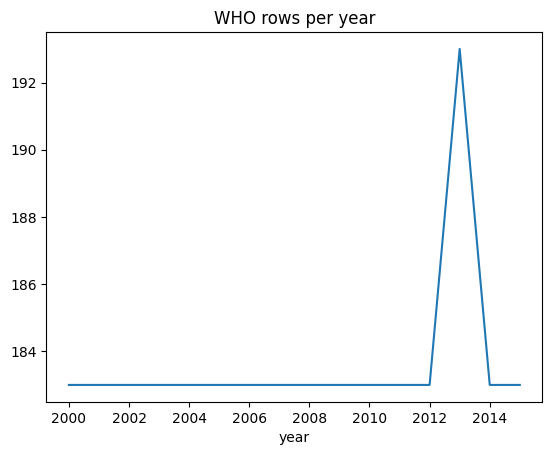

In [32]:
who.groupby("year").size().plot(title="WHO rows per year")
plt.show()

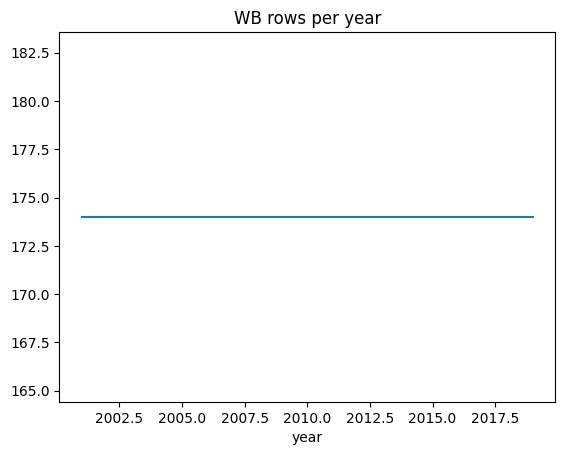

In [33]:
wb.groupby("year").size().plot(title="WB rows per year")
plt.show()